# Risco de crédito: do CSV ao veredito

Este notebook percorre as seis Etapas do projeto. Execute as células em ordem, a partir da pasta do projeto. O processamento lê os CSVs originais, grava as saídas em `resultados/` e `dados_derivados/` e confere os arquivos de entrada por hash. O alvo positivo, `loan_status=1`, indica inadimplência.

Os textos abaixo explicam as decisões. A implementação está em `notebooks/pipeline_credito.py`; as funções indicadas em cada fase permitem conferir o processamento.


In [1]:
from pathlib import Path
import sys, os, runpy
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'credit_risk_dataset.csv').exists(), 'Abra o notebook na pasta do projeto.'
sys.path.insert(0, str(ROOT / 'notebooks'))
os.environ.setdefault('MPLCONFIGDIR', '/tmp/credito-matplotlib')

def secao(caminho, titulo_h2):
    """Recorta, de um dos .md consolidados, só a seção que começa em '## <titulo_h2>'
    e vai até o próximo '## ' (ou até o fim do arquivo)."""
    texto = (ROOT / caminho).read_text()
    marcador = '## ' + titulo_h2
    inicio = texto.index(marcador)
    resto = texto[inicio:]
    fim = resto.find('\n## ', len(marcador))
    return (resto if fim == -1 else resto[:fim]).strip()


## Primeiro, reproduzir as análises

A próxima célula roda o pipeline completo (`03_executar_pipeline.py`): limpeza, variável calculada, separação, validação cruzada, seleção de hiperparâmetros e avaliação no teste. Refaz os arquivos de saída; não modifica os CSVs originais. A cadeia completa de scripts está descrita na seção "Reprodução" do README.


In [2]:
_ = runpy.run_path(str(ROOT / 'notebooks/03_executar_pipeline.py'), run_name='__main__')


EDA gerada; integridade dos CSVs confirmada.


Validação: dobra 1/5 concluída.


Validação: dobra 2/5 concluída.


Validação: dobra 3/5 concluída.


Validação: dobra 4/5 concluída.


Validação: dobra 5/5 concluída.


Pipeline concluído; oito configurações e integridade verificadas.


## 1. Análise exploratória

`02_eda_graficos.py` lê a base original e produz 6 gráficos. Comece pelo inventário: confira 32.581 linhas, 12 colunas, tipos e nulos. Depois compare as classes, a renda e a razão empréstimo/renda. O mapa de correlação mostra associação, não causa. A EDA descreve toda a base e não é uma avaliação cega do teste.


## 1. Análise exploratória (EDA)

### Distribuição do alvo

A inadimplência representa 21,82% dos registros. Há diferença relevante entre as classes; o split deverá preservar a proporção e a avaliação usará recall, precisão e F1 além da acurácia. O balanceamento, quando aplicado, ficará restrito ao treino.

### Renda anual

A mediana da renda é 60.000 para contratos em dia e 41.498 para contratos inadimplentes. O histograma usa intervalos comuns e eixo logarítmico, sem remover registros. Cada classe é normalizada separadamente; a altura mostra sua fração no intervalo. Valores altos não demonstram erro por si sós.

### Comprometimento da renda

As medianas de `loan_percent_income` são 0,130 para a classe 0 e 0,240 para a classe 1. A correlação de Pearson com o alvo é 0,379; isso é associação descritiva, não causalidade.

### Outliers: renda e valor do empréstimo

O critério de referência é o limite superior do boxplot (Q3 + 1,5×IQR), usado só para
visualizar a cauda, não como regra de exclusão. Por esse critério, 1.484
registros de `person_income` ficam acima de 140.250 e
1.689 registros de `loan_amnt` ficam acima de
23.000. O gráfico 06 mostra essas caudas por status, em escala
logarítmica. A decisão (seção 2 abaixo) é manter esses valores: são extremos raros e
plausíveis (rendas e empréstimos altos existem), não erros de digitação como as idades de
123/144 anos. Essa manutenção pesa mais no KNN, sensível a distâncias euclidianas mesmo após
o StandardScaler, do que na árvore, que corta por limiar e é robusta à magnitude dos valores.

### Valores ausentes

`person_emp_length` tem 895 valores ausentes e `loan_int_rate` tem 3.116. A mediana será usada para o tempo de emprego porque a distribuição é assimétrica; a média será usada para a taxa porque média e mediana são próximas. Esses valores são aprendidos somente no treino de cada dobra, depois do split.

### Correlações e próximos passos

A correlação entre `loan_status` e `loan_int_rate` é 0,335. Correlação não determina exclusão automática nem causalidade. A preparação (seções 2 a 4) remove repetições exatas e idades de 123/144 anos, invalida dois tempos de emprego impossíveis, mantém rendas extremas plausíveis, substitui a razão redundante pela coluna exigida e aprende imputadores somente no treino. Esta EDA descreve toda a base; não é uma análise cega de holdout.

As figuras ficam em `resultados/graficos_eda/`. O gráfico 05 resume os nulos observados antes da imputação e o gráfico 06 mostra os outliers de renda e valor do empréstimo por status. Os CSVs foram apenas lidos e tiveram seus hashes conferidos antes e depois da execução.

,Unnamed: 0,tipo,nulos
0,person_age,int64,0
1,person_income,int64,0
2,person_home_ownership,str,0
3,person_emp_length,float64,895
4,loan_intent,str,0
5,loan_grade,str,0
6,loan_amnt,int64,0
7,loan_int_rate,float64,3116
8,loan_status,int64,0
9,loan_percent_income,float64,0


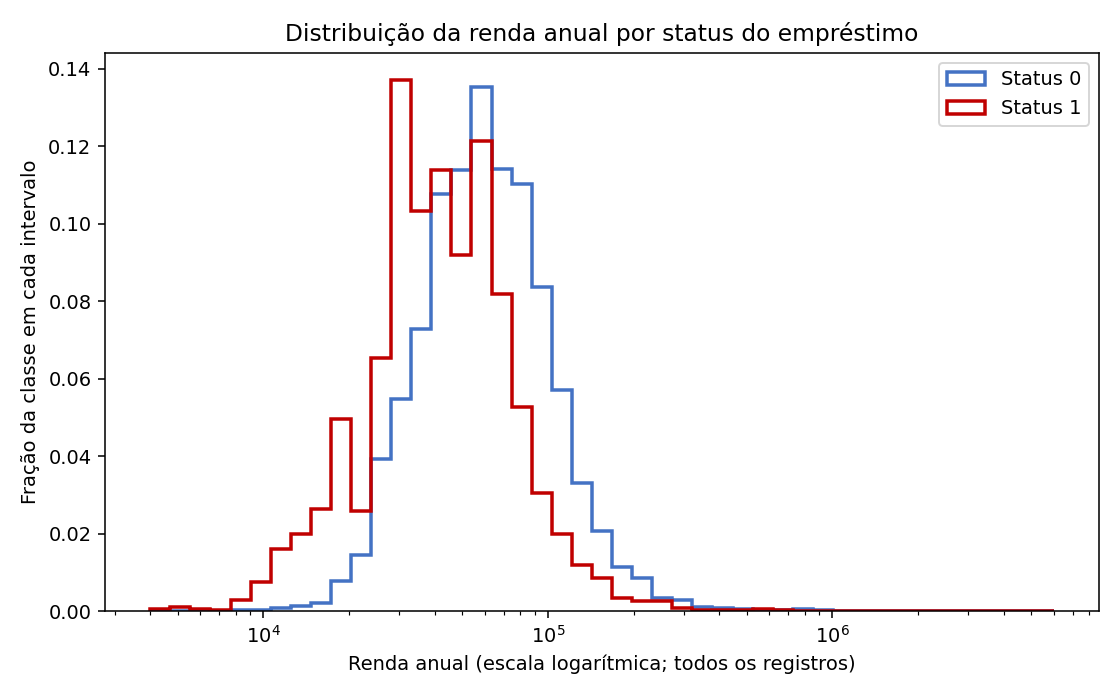

In [3]:
display(Markdown(secao('documentacao/01_eda_e_preparacao.md', '1. Análise exploratória (EDA)')))
display(pd.read_csv(ROOT / 'resultados/graficos_eda/inventario.csv'))
display(Image(filename=str(ROOT / 'resultados/graficos_eda/02_histograma_renda_status.png')))


Dimensões originais: (32581, 12)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


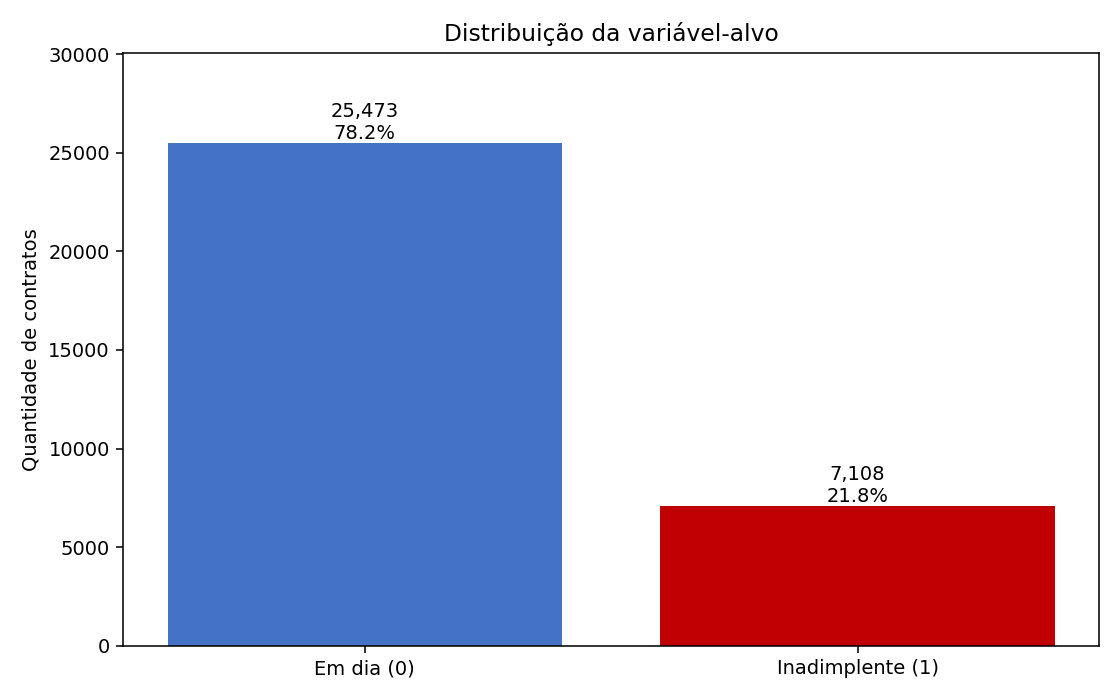

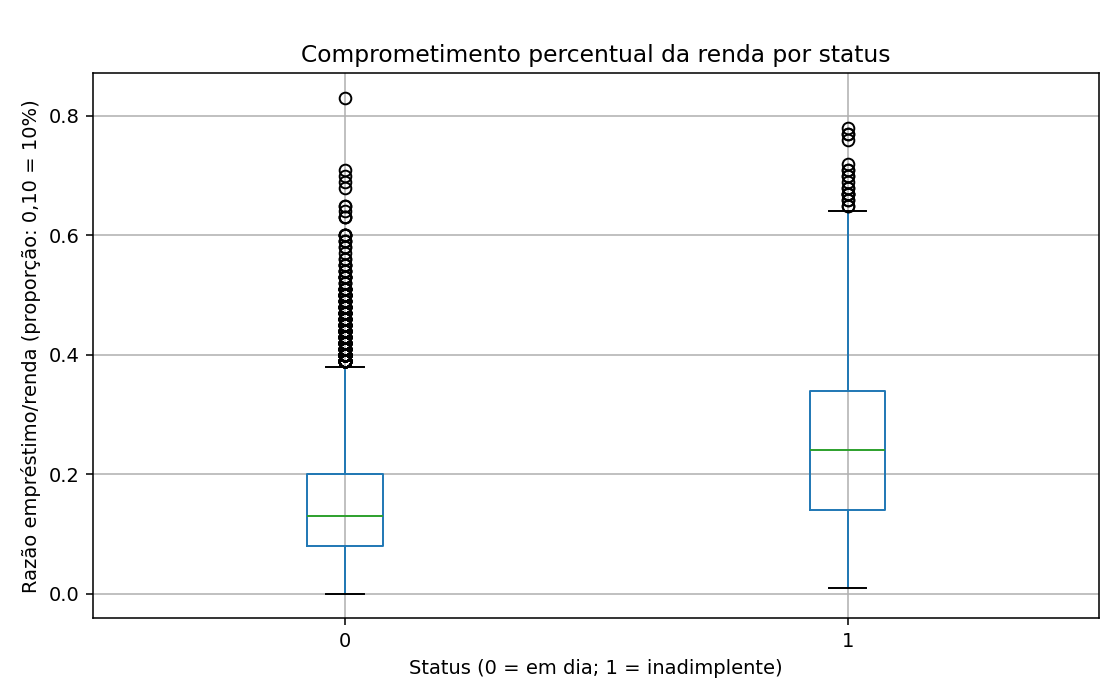

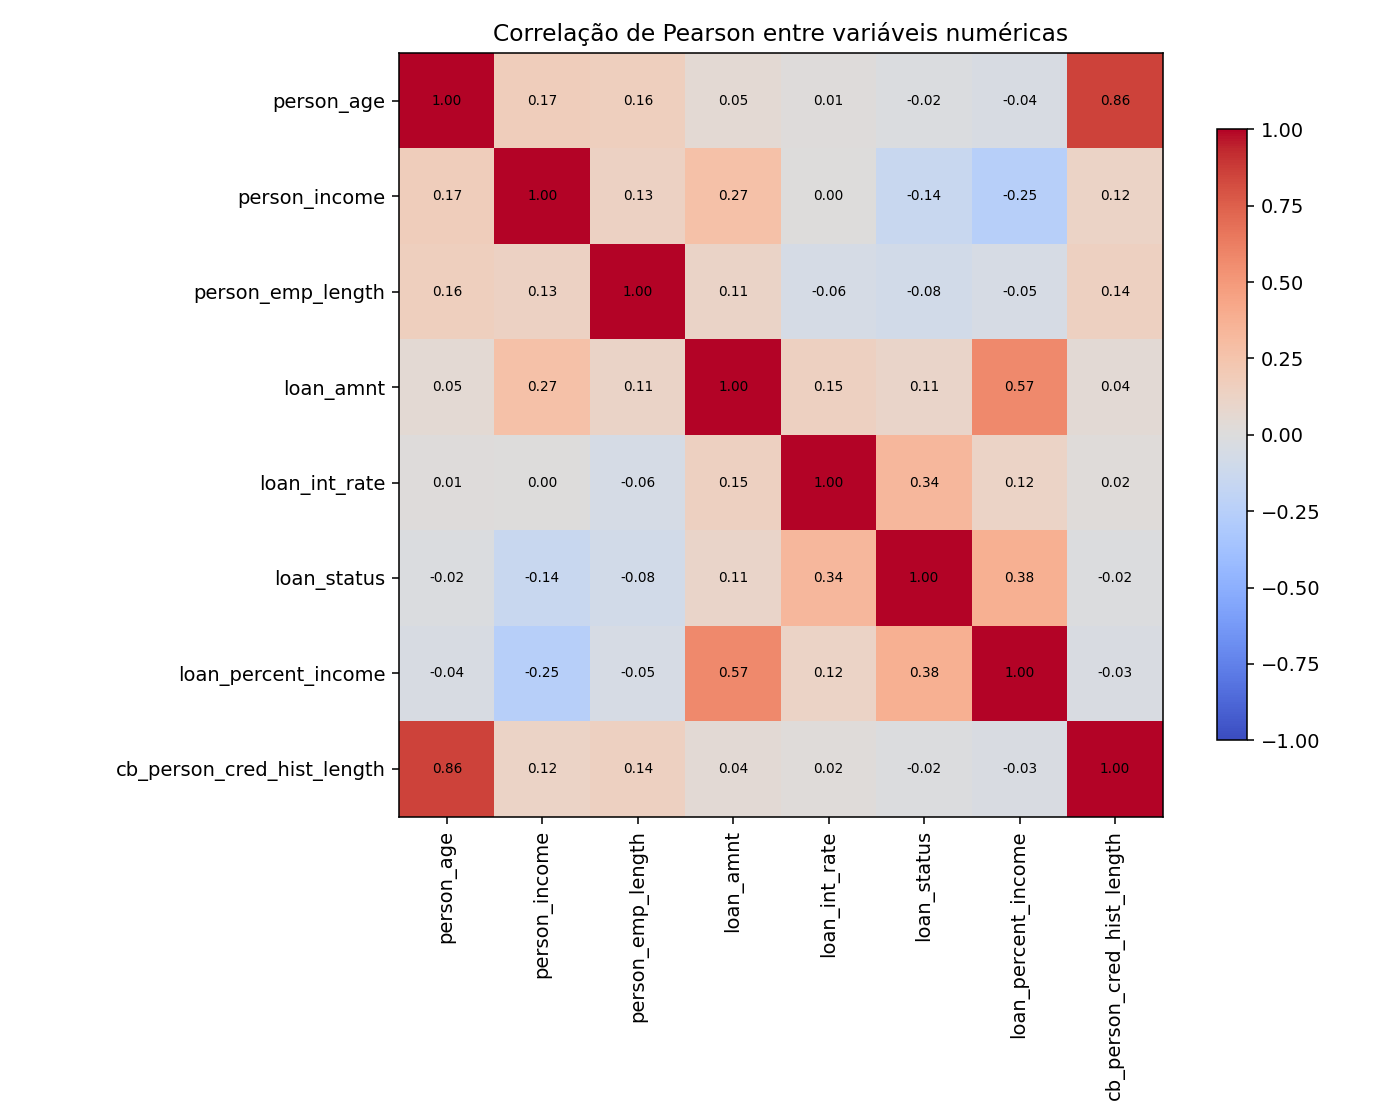

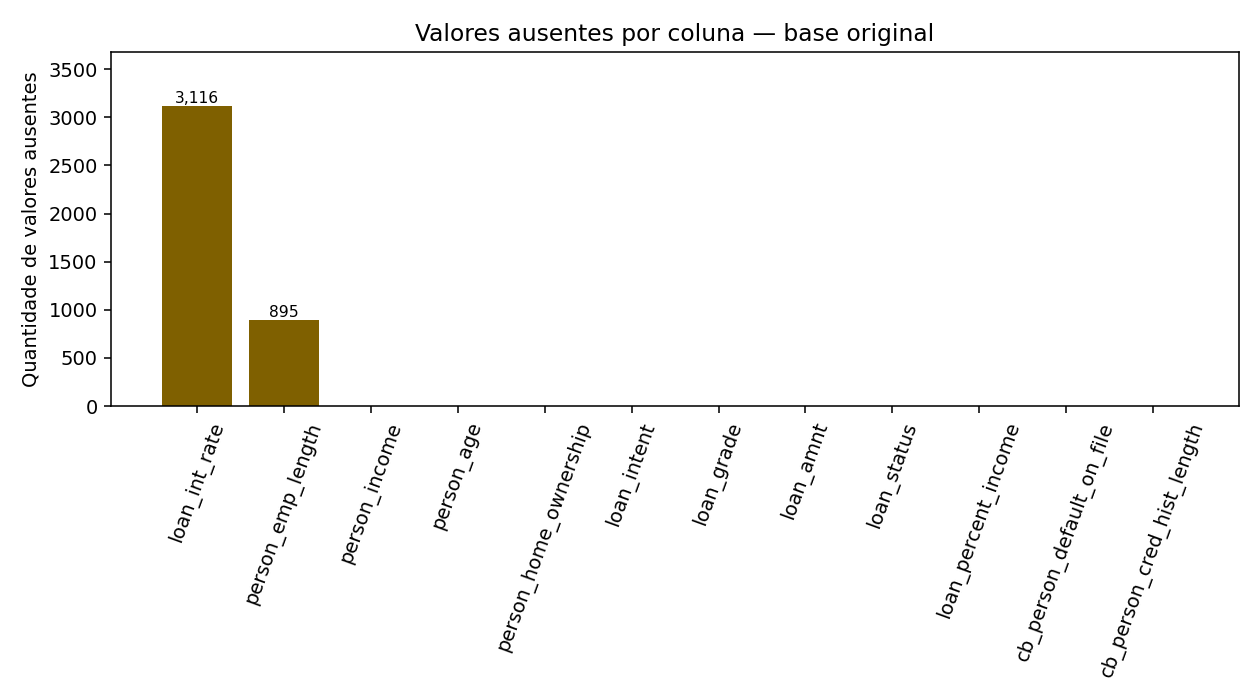

In [4]:
raw = pd.read_csv(ROOT / 'credit_risk_dataset.csv')
print('Dimensões originais:', raw.shape)
display(raw.describe())
for name in ['01_distribuicao_alvo', '03_boxplot_comprometimento', '04_correlacao_pearson', '05_valores_nulos']:
    display(Image(filename=str(ROOT / f'resultados/graficos_eda/{name}.png')))


## 2. Limpeza

Em `clean_data()`, `drop_duplicates()` retira 165 repetições exatas; cinco idades de 123 ou 144 anos saem da cópia de trabalho. Dois tempos de emprego de 123 anos, incompatíveis com a idade das pessoas, viram nulos. As rendas extremas ficam porque raridade, sozinha, não prova erro — essa decisão está detalhada, com o boxplot de outliers, na seção 2 de `documentacao/01_eda_e_preparacao.md` (já exibida acima). A base limpa tem 32.411 linhas. A imputação ainda não ocorre aqui: ela será ajustada no treino de cada dobra.


In [5]:
display(Markdown(secao('documentacao/01_eda_e_preparacao.md', '2. Limpeza e imputação')))
display(pd.read_csv(ROOT / 'resultados/estatisticas_treino.csv'))

# Código da Etapa 2 (limpeza), exatamente como executado pelo pipeline
from inspect import getsource
import pipeline_credito as pc
print(getsource(pc.clean_data))


## 2. Limpeza e imputação

Foram removidas 165 repetições exatas, mantendo a primeira ocorrência.
Sem identificador de cliente, igualdade não prova que sejam a mesma pessoa; a opção segue a exigência
da estudo de remover redundâncias e evita casos idênticos nas duas partições.

A exclusão por idade usa uma regra explícita de plausibilidade para este estudo: idade >=120.
Os registros observados tinham [144, 144, 123, 123, 144]; não há idades entre 101 e 119.
Não afirmamos que toda idade acima de 100 seja impossível. As idades extremas repetidas,
sem possibilidade de confirmar a informação na fonte, foram excluídas desta análise —
diferente da renda e do valor do empréstimo (seção 1), mantidos por serem extremos plausíveis,
não erros de digitação. A regra é uma decisão de qualidade de dados, não uma política de
concessão de crédito. A lista está em resultados/idades_excluidas.csv.

Dois tempos de emprego de 123 anos em pessoas de 21 e 22 anos foram convertidos em nulos
antes de qualquer separação. As outras colunas dessas linhas foram preservadas.
A base ficou com 32411 linhas.

### Estatísticas somente do treino

| Variável | Média | Mediana | Assimetria | Nulos |
| --- | --- | --- | --- | --- |
| person_emp_length | 4,7784 | 4,0000 | 1,2259 | 717 |
| loan_int_rate | 11,0133 | 10,9900 | 0,2014 | 2.482 |

Tempo de emprego: mediana, porque a cauda direita permanece após corrigir os erros;
a mediana é menos influenciada por valores altos. Taxa de juros: média, porque média e
mediana são próximas e a assimetria é pequena. Essas são escolhas prévias à seleção
dos modelos. Cada dobra aprende seus próprios valores; o ajuste final usa todo o treino.
As demais numéricas têm mediana como regra de contingência, mas não apresentam nulos nesta base.

Valores extremos podem deslocar as distâncias do KNN mesmo após StandardScaler, que não
é um tratamento robusto de outliers. A árvore dispensa escala e é menos sensível à magnitude,
mas ainda pode aprender cortes inadequados com registros errados. Essa limitação é registrada.

Os CSVs originais são verificados por hash. A rastreabilidade é armazenada separadamente
em dados_derivados/origens.csv e nunca entra nos preditores.

,Unnamed: 0,count,mean,median,std,min,max,skew,nulos
0,person_age,25928.0,27.694500,26.000000,6.176875,20.00000,94.00,1.936426,0
1,person_income,25928.0,65748.270441,55000.000000,52144.459305,4000.00000,2039784.00,9.693959,0
2,person_emp_length,25211.0,4.778351,4.000000,4.021952,0.00000,38.00,1.225923,717
3,loan_amnt,25928.0,9575.669161,8000.000000,6305.528961,500.00000,35000.00,1.190090,0
4,loan_int_rate,23446.0,11.013347,10.990000,3.233262,5.42000,23.22,0.201438,2482
5,cb_person_cred_hist_length,25928.0,5.794315,4.000000,4.046429,2.00000,30.00,1.664362,0
6,comprometimento_renda,25928.0,17.057704,14.814815,10.717736,0.21097,83.00,1.065463,0


def clean_data():
    verify_originals()
    raw = pd.read_csv(ROOT / "credit_risk_dataset.csv")
    clean = raw.drop_duplicates().copy()
    # O índice original é rastreabilidade, nunca um preditor.
    clean.index.name = "origem_linha"
    excluded = clean.loc[clean.person_age >= 120].copy()
    clean = clean.loc[clean.person_age < 120].copy()
    invalid_emp = clean.person_emp_length.ge(clean.person_age) | clean.person_emp_length.lt(0)
    emp_rows = clean.loc[invalid_emp, ["person_age", "person_emp_length"]].copy()
    clean.loc[invalid_emp, "person_emp_length"] = np.nan
    folder = ROOT / "dados_derivados"
    folder.mkdir(exist_ok=True)
    clean.to_csv(folder / "credito_sem_duplicatas_e_idades_invalidas.csv", index=False)
    out = ROOT / "resultados"
    out.mkdir(exist_ok=True)
    excluded.to_csv(out / "idades_excluidas.csv")
    emp_rows.to_csv(out / "emprego_invalidado.csv")
    pd.DataFrame({"origem_linha": clean.index}).to_csv(folder / "origens.csv", index=False)
    wri

## 3. Variável calculada

`safe_ratio()` verifica se empréstimo e renda são finitos e positivos antes da divisão; `add_feature()` cria `comprometimento_renda`. Detalhes na seção abaixo.


In [6]:
display(Markdown(secao('documentacao/01_eda_e_preparacao.md', '3. Engenharia de atributos')))

# Código da Etapa 3: a divisão só acontece depois de validar os operandos (sem NaN ou infinito)
for f in (pc.safe_ratio, pc.add_feature):
    print(getsource(f))


## 3. Engenharia de atributos

A variável derivada é (loan_amnt / person_income) * 100. Ela relaciona o valor total
do empréstimo à renda anual informada; não mede parcela mensal nem comprometimento mensal.

Ambos os operandos são verificados quanto a nulos, infinitos e valores não positivos
antes da divisão. O cálculo mascarado não executa divisões inválidas.
Nesta base não há operandos inválidos: 32411 razões finitas e
0 nulos. Se houver operandos inválidos em outra base, a etapa interrompe
em vez de imputar globalmente; eventual imputação deve ocorrer somente no treino.

loan_percent_income está em proporção; comprometimento_renda está em percentual.
A diferença mediana entre as duas, na mesma unidade, é
0,2500 ponto percentual.
98,68% das linhas diferem em até 0,5001 ponto.
A versão original é retirada dos preditores para evitar peso redundante no KNN.
Não se trata de colinearidade estrita comprovada.

def safe_ratio(amount, income):
    """Recusa operandos inválidos antes de efetuar qualquer divisão."""
    a, b = np.asarray(amount, dtype=float), np.asarray(income, dtype=float)
    valid = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)
    result = np.full(a.shape, np.nan)
    np.divide(a, b, out=result, where=valid)
    return result * 100

def add_feature(clean):
    data = clean.copy()
    data["comprometimento_renda"] = safe_ratio(data.loan_amnt, data.person_income)
    if data.comprometimento_renda.isna().any():
        raise ValueError("Operandos inválidos: tratar no treino antes de criar a razão.")
    assert np.isfinite(data.comprometimento_renda).all()
    data.to_csv(ROOT / "dados_derivados/credito_com_feature.csv", index=False)
    error = (data.comprometimento_renda - data.loan_percent_income * 100).abs()
    write_json(ROOT / "resultados/feature.json", {
        "nulos": int(data.comprometimento_renda.isna().sum()),
        "finitos": int(np.isfinite(data.compromet

## 4. Separação e preparação sem vazamento

`split_data()` separa treino e teste; `prepare()` ajusta imputação, codificação, balanceamento e escala só no treino recebido. Detalhes na seção abaixo.


In [7]:
display(Markdown(secao('documentacao/01_eda_e_preparacao.md', '4. Separação, balanceamento e escalonamento')))

# Código da Etapa 4: split 80/20 estratificado e Random Over-Sampling aplicado só no treino
for f in (pc.split_data, pc.oversample_indices):
    print(getsource(f))


## 4. Separação, balanceamento e escalonamento

Split 80/20 com stratify=y e random_state=42: 25928 linhas de treino e
6483 de teste. A identidade é o número da linha no CSV original (base zero).
Os índices e as repetições estão em resultados/indices_split.csv e
resultados/indices_treino_balanceado.csv.

Imputação e One-Hot Encoding são ajustados somente no treino de cada dobra.
A validação recebe apenas transform. O balanceamento usa Random Over-Sampling: mantém
cada linha original de treino e acrescenta cópias aleatórias, com reposição, apenas da
classe minoritária até igualar as contagens.

**Escolha da técnica de balanceamento — comparação deliberada.** O problema cita, como
exemplo, SMOTE ou Random Under Sampling. Avaliamos as três opções e optamos pelo Random
Over-Sampling por dois motivos, cada um comparado à técnica sugerida correspondente:
frente ao Random Under Sampling, o Random Over-Sampling preserva 100% das linhas
originais da classe majoritária no treino — o undersampling descartaria linhas reais só
para igualar as contagens; frente ao SMOTE, o Random Over-Sampling nunca gera pontos
sintéticos interpolados no espaço de atributos — toda linha do treino balanceado,
original ou repetida, é uma observação real da base, o que facilita a auditoria de
rastreabilidade (resultados/indices_treino_balanceado.csv) e evita introduzir
combinações de atributos que não ocorreram de fato. Não é desconhecimento das técnicas
citadas no problema; é uma escolha justificada entre as três. O ajuste final tem
40514 linhas balanceadas, preservando todas as 25928
originais do treino. As duas famílias recebem exatamente os mesmos índices balanceados.

StandardScaler é ajustado depois do balanceamento, exclusivamente para o KNN. Somente
renda, tempo de emprego, valor do empréstimo, taxa de juros e comprometimento_renda são
escalonados. Idade e duração do histórico, registradas em anos inteiros, são tratadas como
discretas e ficam sem escala; as dummies também não são escalonadas. A árvore usa todas as
variáveis sem escala: seus cortes são baseados em limiares por variável, monotônicos e
independentes de mudanças de escala, então escalonar não mudaria o modelo, só adicionaria
uma etapa sem efeito.

Nenhum parâmetro estatístico é aprendido no teste. Há auditoria de sobreposição de origem
e de preservação dos registros nas cinco dobras e no ajuste final.

### Limitação conhecida

O teste só é usado depois que os hiperparâmetros são escolhidos por validação cruzada (5 dobras, só no treino). Como a base completa foi examinada durante o desenvolvimento deste projeto, o teste não tem a independência de uma amostra nunca vista antes; a seleção, porém, não consulta o teste em nenhuma etapa.

def split_data(data):
    X = data.drop(columns=["loan_status", "loan_percent_income"])
    y = data.loan_status
    train, test = train_test_split(
        np.arange(len(data)), test_size=0.20, stratify=y, random_state=SEED
    )
    assert not set(data.index[train]) & set(data.index[test])
    return X.iloc[train], X.iloc[test], y.iloc[train], y.iloc[test]

def oversample_indices(y, seed=SEED):
    """Random Over-Sampling: inclui cada linha original uma vez e acrescenta cópias
    aleatórias, com reposição, apenas do déficit das classes minoritárias.

    Escolha deliberada em vez das duas técnicas sugeridas no problema (SMOTE e Random
    Under Sampling), comparadas explicitamente:
    - vs. Random Under Sampling: preserva as 100% das linhas originais da classe
      majoritária no treino; undersampling descartaria linhas reais.
    - vs. SMOTE: nunca gera pontos sintéticos interpolados; toda linha resultante,
      original ou repetida, é uma observação real da base.
    Aplicada e

### Trecho do código: preparação

A célula abaixo exibe a função `prepare()` diretamente do arquivo usado na execução. Observe a ordem: `fit_transform` no treino, `transform` na avaliação, balanceamento só no treino e escala só no KNN. É a mesma função que produziu as métricas.

In [8]:
from inspect import getsource
from pipeline_credito import prepare
print(getsource(prepare))

def prepare(Xtrain, ytrain, Xeval):
    # Taxa de juros é quase simétrica: média; emprego tem cauda direita: mediana.
    numeric = Xtrain.select_dtypes(include="number").columns.tolist()
    median_cols = [c for c in numeric if c != "loan_int_rate"]
    categorical = Xtrain.select_dtypes(exclude="number").columns.tolist()
    transformer = ColumnTransformer([
        ("mediana", SimpleImputer(strategy="median"), median_cols),
        ("juros", SimpleImputer(strategy="mean"), ["loan_int_rate"]),
        ("categoria", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
    ])
    original = transformer.fit_transform(Xtrain)
    evaluation = transformer.transform(Xeval)
    names = transformer.get_feature_names_out().tolist()
    balanced_indices = oversample_indices(ytrain)
    balanced = original[balanced_indices].copy()
    balanced_y = ytrain.to_numpy()[balanced_indices]
    scale_indices = [
        i for i, name in enumerate(names) if name.split("__", 1)[1] i

## 5. KNN, árvore e sobreajuste

`run_cv()` compara K=3, 5, 7 e 9 no KNN e profundidades 3, 5, 7 e ilimitada na árvore, em cinco dobras estratificadas. Em cada dobra, `prepare()` reaprende as transformações usando somente o treino daquela dobra. Compare F1 de treino e validação nas curvas: a árvore ilimitada chega a F1=1,0000 no treino, mas cai na validação. `select_configs()` escolhe o maior F1 médio de validação da classe 1; os vencedores foram K=9 e profundidade 7. As curvas também mostram o teste para análise posterior, não para escolher os parâmetros.


# Modelagem: KNN e Árvore de Decisão

Testamos 4 valores de K no KNN (3, 5, 7, 9) e 4 profundidades na árvore (3, 5, 7 e
ilimitada), sempre comparando F1 de treino contra F1 de validação em 5 dobras
estratificadas, para diagnosticar overfitting antes de tocar no teste.

## KNN (n_neighbors)

| Parâmetro | F1 treino (CV) | F1 validação (CV) | Desvio (CV) | F1 treino (final) | F1 teste (final) | Gap treino→teste (final) |
| --- | --- | --- | --- | --- | --- | --- |
| 3 | 0,8444 | 0,5925 | 0,0107 | 0,8458 | 0,6018 | 0,2440 |
| 5 | 0,7586 | 0,5832 | 0,0076 | 0,7612 | 0,5931 | 0,1680 |
| 7 | 0,7197 | 0,5898 | 0,0031 | 0,7245 | 0,5985 | 0,1259 |
| 9 | 0,7048 | 0,5984 | 0,0040 | 0,7083 | 0,6031 | 0,1051 |

As duas primeiras colunas de F1 (treino e validação) vêm da validação cruzada em 5
dobras, feita só no treino, antes de tocar no teste — é nelas que a seleção se baseia.
As três últimas (treino, teste e o gap entre eles) vêm do ajuste final, feito depois da
seleção, e servem só para descrever o resultado no teste; não influenciam a escolha.

A seleção foi 9, com F1 médio de validação 0,5984.
Usamos o maior F1 médio; em empate exato, K maior no KNN e menor profundidade na árvore.

O intervalo observado do gap treino-validação é 0,1064 a
0,2519. Quanto maior a vantagem no treino, maior o indício de ajuste excessivo;
não aplicamos um limite arbitrário para eliminar modelos.

### Diagnóstico de overfitting

No KNN, K=3 teve F1 médio de treino 0,8444 e F1 de validação 0,5925, um gap de 0,2519. Com K=9, o F1 de treino caiu para 0,7048, mas o F1 de validação subiu para 0,5984 e o gap caiu para 0,1064. Por isso K=9 foi escolhido: ele generalizou melhor entre os quatro valores testados, apesar de a diferença de validação ser pequena.

![Curva de treino, validação e teste — KNN (n_neighbors)](../resultados/avaliacao_final/curva_validacao_knn.png)

## Árvore de Decisão (max_depth)

| Parâmetro | F1 treino (CV) | F1 validação (CV) | Desvio (CV) | F1 treino (final) | F1 teste (final) | Gap treino→teste (final) |
| --- | --- | --- | --- | --- | --- | --- |
| 3 | 0,7079 | 0,7060 | 0,0093 | 0,7083 | 0,7179 | -0,0096 |
| 5 | 0,7368 | 0,7331 | 0,0073 | 0,7280 | 0,7220 | 0,0060 |
| 7 | 0,7715 | 0,7551 | 0,0117 | 0,7865 | 0,7674 | 0,0191 |
| None | 1,0000 | 0,7481 | 0,0039 | 1,0000 | 0,7561 | 0,2439 |

As duas primeiras colunas de F1 (treino e validação) vêm da validação cruzada em 5
dobras, feita só no treino, antes de tocar no teste — é nelas que a seleção se baseia.
As três últimas (treino, teste e o gap entre eles) vêm do ajuste final, feito depois da
seleção, e servem só para descrever o resultado no teste; não influenciam a escolha.

A seleção foi 7, com F1 médio de validação 0,7551.
Usamos o maior F1 médio; em empate exato, K maior no KNN e menor profundidade na árvore.

O intervalo observado do gap treino-validação é 0,0018 a
0,2519. Quanto maior a vantagem no treino, maior o indício de ajuste excessivo;
não aplicamos um limite arbitrário para eliminar modelos.

### Diagnóstico de overfitting

Na árvore sem limite de profundidade, o F1 de treino chegou a 1,0000, enquanto o F1 de validação foi 0,7481; o gap de 0,2519 é o sinal mais claro de memorização. A profundidade 7 manteve F1 de treino 0,7715, obteve o maior F1 de validação (0,7551) e reduziu o gap para 0,0164.

![Curva de treino, validação e teste — Árvore de Decisão (max_depth)](../resultados/avaliacao_final/curva_overfitting_arvore.png)


,model,param,cv_f1,cv_std,train_accuracy_mean,train_accuracy_std,train_precision_1_mean,train_precision_1_std,train_recall_1_mean,train_recall_1_std,...,treino_accuracy,treino_precision_1,treino_recall_1,treino_f1_1,teste_accuracy,teste_precision_1,teste_recall_1,teste_f1_1,gap_f1,selecionado
0,KNN,3.0,0.592515,0.010737,0.921311,0.001185,0.744032,0.002555,0.976018,0.001484,...,0.922131,0.746025,0.976371,0.845795,0.799784,0.532573,0.691819,0.601840,0.243955,False
1,KNN,5.0,0.583203,0.007608,0.869909,0.002330,0.638488,0.004507,0.934271,0.003103,...,0.871722,0.642035,0.934579,0.761166,0.780349,0.498559,0.732017,0.593143,0.168023,False
2,KNN,7.0,0.589806,0.003086,0.847308,0.002785,0.601347,0.005208,0.896006,0.002981,...,0.850933,0.608066,0.895962,0.724460,0.781891,0.500951,0.743300,0.598524,0.125936,False
3,KNN,9.0,0.598411,0.004008,0.840327,0.003123,0.591730,0.005811,0.871231,0.002126,...,0.843837,0.598806,0.866690,0.708264,0.786056,0.507463,0.743300,0.603147,0.105117,True
4,Tree,3.0,0.706022,0.009311,0.874990,0.002024,0.724168,0.009120,0.692427,0.005959,...,0.877507,0.739122,0.679951,0.708303,0.881536,0.749233,0.688999,0.717855,-0.009552,False
5,Tree,5.0,0.733086,0.007345,0.884333,0.004353,0.734036,0.016933,0.739993,0.006018,...,0.878008,0.710473,0.746429,0.728008,0.874904,0.702468,0.742595,0.721975,0.006033,False
6,Tree,7.0,0.755135,0.011733,0.902471,0.009151,0.794928,0.040485,0.750969,0.011214,...,0.911756,0.835282,0.743079,0.786487,0.902823,0.805426,0.732722,0.767356,0.019132,True
7,Tree,NaN,0.748119,0.003894,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,0.892951,0.753501,0.758815,0.756149,0.243851,False


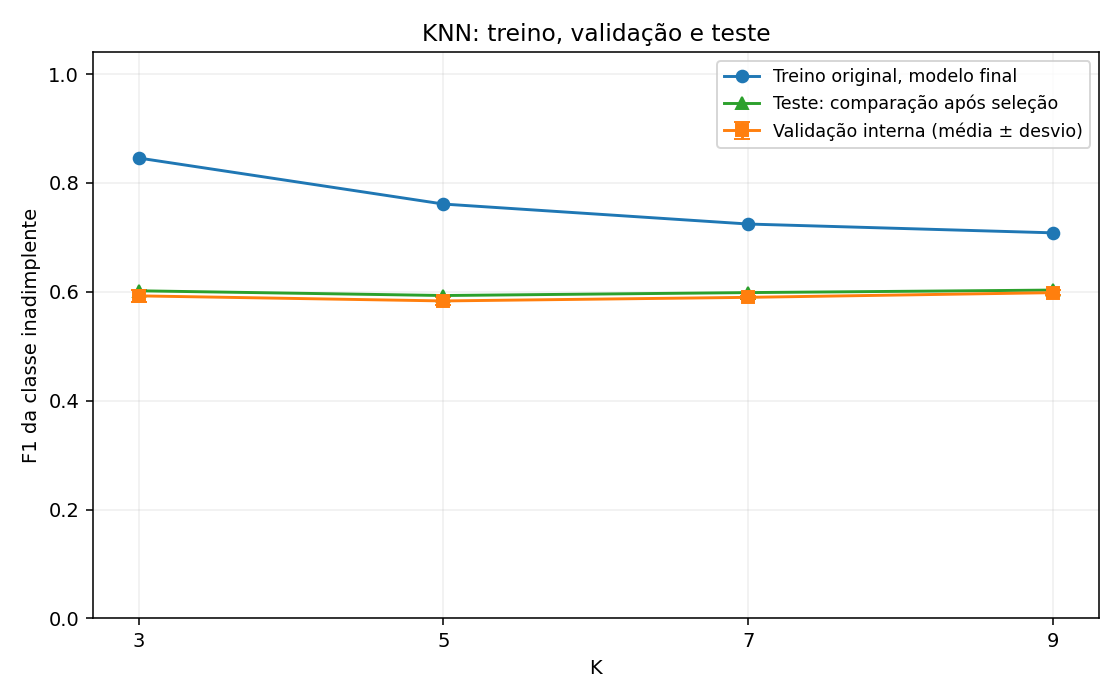

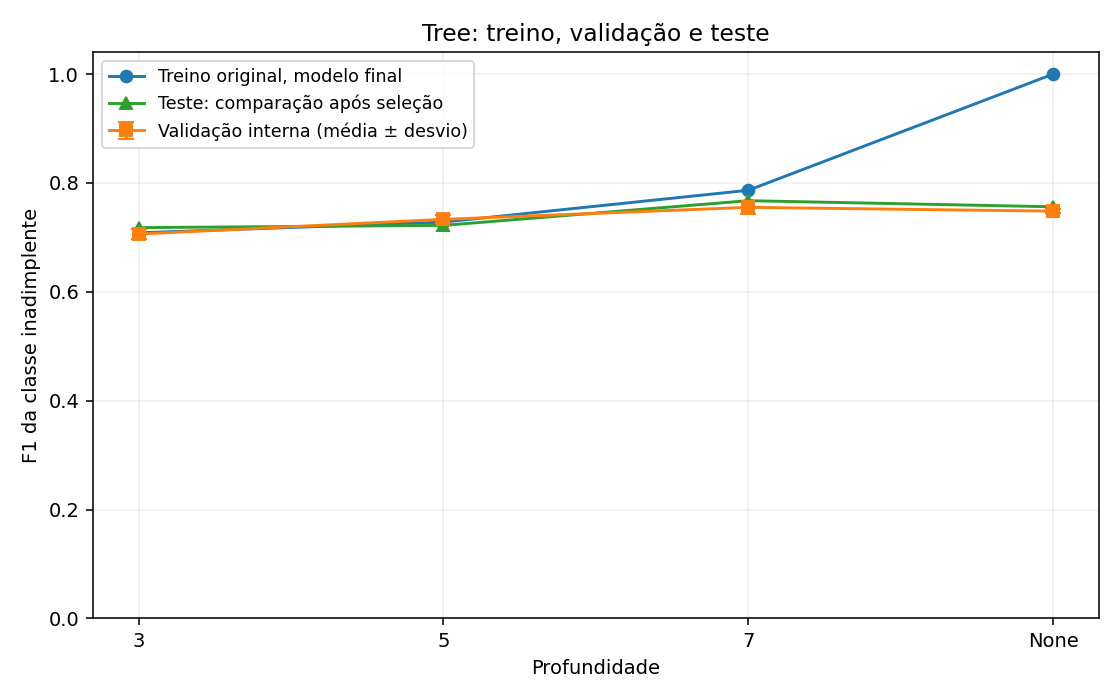

In [9]:
display(Markdown((ROOT / 'documentacao/02_modelagem.md').read_text()))
display(pd.read_csv(ROOT / 'resultados/experimentos.csv'))
display(Image(filename=str(ROOT / 'resultados/avaliacao_final/curva_validacao_knn.png')))
display(Image(filename=str(ROOT / 'resultados/avaliacao_final/curva_overfitting_arvore.png')))


In [10]:
# Código da Etapa 5: escolha dos hiperparâmetros pelo F1 médio de validação (antes do teste)
print(getsource(pc.select_configs))


def select_configs(rows):
    selected = {}
    for kind in ("KNN", "Tree"):
        candidates = [r for r in rows if r["model"] == kind]
        # Empates exatos: K maior suaviza KNN; profundidade menor simplifica árvore.
        def key(r):
            param = r["param"]
            simplicity = int(param) if kind == "KNN" else -(999 if param == "None" else int(param))
            return r["cv_f1"], simplicity
        selected[kind] = max(candidates, key=key)["param"]
    return selected



## 6. Avaliação e decisão de negócio

`model_artifacts()` gera o relatório de classificação e a matriz de confusão dos dois finalistas. Na matriz, falso positivo é um bom pagador marcado como risco; falso negativo é um inadimplente não detectado. A simulação de custos usa R$ 1.000 por FP e R$ 5.000 por FN apenas para comparar cenários. Nesse cenário, a árvore tem custo menor, mas isso não equivale a economia observada pelo banco.


# Avaliação final e veredito de negócio

## Avaliação final

| Modelo | Parâmetro | Acurácia | Precisão (1) | Recall (1) | F1 (1) | FP | FN |
| --- | --- | --- | --- | --- | --- | --- | --- |
| KNN | 9 | 0,7861 | 0,5075 | 0,7433 | 0,6031 | 1.023 | 364 |
| Árvore | 7 | 0,9028 | 0,8054 | 0,7327 | 0,7674 | 251 | 379 |

A classe positiva é inadimplência. FP é um bom pagador previsto como inadimplente;
FN é um inadimplente previsto como bom pagador. A previsão não é, por si só, uma
decisão efetiva de conceder ou recusar crédito.

### Comparação de erros

Em relação ao KNN, a árvore comete 15 FN a mais
e 772 FP a menos. A árvore tem menor custo se custo_FN/custo_FP for menor que 51,467; no ponto há empate. Na relação oposta, o KNN tem menor custo.

### Cenário de custos ilustrativos

Para demonstrar o cálculo, usamos custo_FP=R$ 1.000 e custo_FN=R$ 5.000.
Esses valores são hipóteses ilustrativas; não são estimativas apuradas,
não vieram da base e não são apresentados como parâmetros representativos de bancos.
Custo hipotético = FP × custo_FP + FN × custo_FN.

| Modelo | Parâmetro | FP | FN | Custo FP (R$) | Custo FN (R$) | Custo total (R$) |
| --- | --- | --- | --- | --- | --- | --- |
| KNN | 9 | 1.023 | 364 | 1.023.000 | 1.820.000 | 2.843.000 |
| Árvore | 7 | 251 | 379 | 251.000 | 1.895.000 | 2.146.000 |

A diferença de R$ 697.000,00 vale apenas para essas contagens e essas hipóteses.
Não é economia realizada, receita prevista ou prova de redução efetiva da inadimplência.

### Veredito: qual erro custa mais e qual modelo vai para produção

**O erro mais caro é o falso negativo (FN).** Um inadimplente aprovado como "seguro"
leva ao prejuízo do valor emprestado. Um falso positivo (bom pagador recusado) custa a
receita de juros daquele contrato e o relacionamento com o cliente, mas não o capital.
Por isso, no cenário ilustrativo, um FN custa 5 vezes mais que um FP.

**Veredito: colocaria em produção a Árvore de Decisão (profundidade máxima 7).** Mesmo com o
FN sendo o erro mais caro, ela sai mais barata pelos números já mostrados acima. Para o
KNN compensar, a perda de um calote teria de valer dezenas de vezes a margem perdida ao
recusar um bom pagador, o que é pouco plausível: a perda máxima de um FN é o próprio valor
emprestado. Por isso a vantagem da árvore resiste à incerteza sobre os custos reais. Ela
também tem o maior F1 no teste (0,7674) e a maior precisão, o que
reduz recusas injustas de bons pagadores. Os parâmetros foram escolhidos só por validação
interna, antes do teste.

Antes do uso real, o banco deve confirmar os custos efetivos de cada erro e se juros e
classificação de risco estão disponíveis no momento da decisão (ver Limitações).

### Importância das variáveis

| Variável | Importância |
| --- | --- |
| comprometimento_renda | 0,3170 |
| loan_int_rate | 0,2691 |
| person_income | 0,1449 |
| person_home_ownership_RENT | 0,0634 |
| loan_grade_D | 0,0524 |

Essas importâncias foram extraídas do MESMO objeto de árvore que produziu as predições
e a matriz deste relatório. Elas representam redução de impureza usada nos cortes,
não contribuição financeira, efeito causal ou percentual da decisão de um cliente.
A razão empréstimo/renda não representa parcela mensal.
Variáveis correlacionadas e a quantidade de cortes disponíveis podem afetar a importância.

### Limitações

O teste só é usado depois que os hiperparâmetros são escolhidos por validação cruzada (5 dobras, só no treino). Como a base completa foi examinada durante o desenvolvimento deste projeto, o teste não tem a independência de uma amostra nunca vista antes; a seleção, porém, não consulta o teste em nenhuma etapa.

Não há datas para demonstrar validação temporal. Taxa de juros e classificação do empréstimo
podem depender da análise de crédito: a base não esclarece em que momento estão disponíveis.
O estudo não demonstra causalidade nem adequação para decisões automatizadas reais.

## Verificação complementar

Esta análise usa apenas as cinco dobras do conjunto de treino. A divisão de teste, a seleção de KNN/Árvore e o veredito principal permanecem inalterados. Gerada por `notebooks/04_analise_complementar.py`, um passo extra opcional (não exigido pelo problema), rodado manualmente depois do pipeline principal.

| Modelo | F1 médio (classe 1) | Desvio entre dobras | Recall médio | Precisão média |
| --- | ---: | ---: | ---: | ---: |
| Referência aleatória estratificada | 0,2219 | 0,0063 | 0,2239 | 0,2200 |
| Árvore completa (profundidade 7) | 0,7551 | 0,0131 | 0,7329 | 0,7814 |
| Árvore sem grade e juros (profundidade 7) | 0,6327 | 0,0076 | 0,6844 | 0,5888 |

A referência aleatória estratificada preserva aproximadamente a proporção das classes, mas não aprende relações entre atributos e alvo.
A árvore reduzida exclui todas as colunas codificadas de `loan_grade` e `loan_int_rate`; mantém a mesma profundidade, as mesmas dobras e os mesmos índices de balanceamento da árvore completa.
A diferença média de F1 (completa menos reduzida) foi 0,1225.
Isso mede sensibilidade nesta base, não demonstra vazamento por si só. É preciso confirmar quando grade e juros ficam disponíveis no processo real.
A profundidade 7 foi fixada a partir da análise principal; não foi otimizada novamente para a versão reduzida. Portanto, esta comparação é exploratória, e não uma nova seleção de modelo.

Resultados por dobra: `resultados/analise_complementar_dobras.csv`. Resumo: `resultados/analise_complementar_resumo.csv`.

## Nota metodológica

Uma única implementação em notebooks/pipeline_credito.py é usada por todas as entradas do
projeto (notebooks/03_executar_pipeline.py e notebooks/pipeline_completo.ipynb).

- Limpeza estrutural antes do split; valores de emprego impossíveis viram nulos.
- Razão protegida, calculada sem imputação global.
- Cinco dobras do treino bruto; transformações e balanceamento dentro de cada dobra.
- Balanceamento por Random Over-Sampling (reamostragem com reposição da classe minoritária), estritamente no treino.
- Mesmos índices balanceados para KNN e árvore.
- Scaler nas contínuas, ajustado no treino balanceado, exclusivo do KNN.
- Seleção persistida antes do teste: {'KNN': '9', 'Tree': '7'}.
- Oito comparações de treino/teste; treino avaliado sem duplicações artificiais.
- Importância extraída da árvore realmente avaliada.
- Simulação financeira calculada a partir das contagens geradas, sem números fixados.
- Este arquivo é regenerado a partir dos mesmos resultados a cada execução do pipeline.

A limitação de dependência do teste histórico está detalhada na seção "Limitações" acima.
A auditoria detalhada está em resultados/auditoria_execucao.json. Os testes de regressão
ficam em tests/test_pipeline.py.


,model,param,prefix,cv_f1,test_accuracy,test_precision_1,test_recall_1,test_f1_1,fp,fn,tn,tp
0,KNN,9,knn_k9,0.598411,0.786056,0.507463,0.743300,0.603147,1023,364,4042,1054
1,Tree,7,arvore_depth7,0.755135,0.902823,0.805426,0.732722,0.767356,251,379,4814,1039


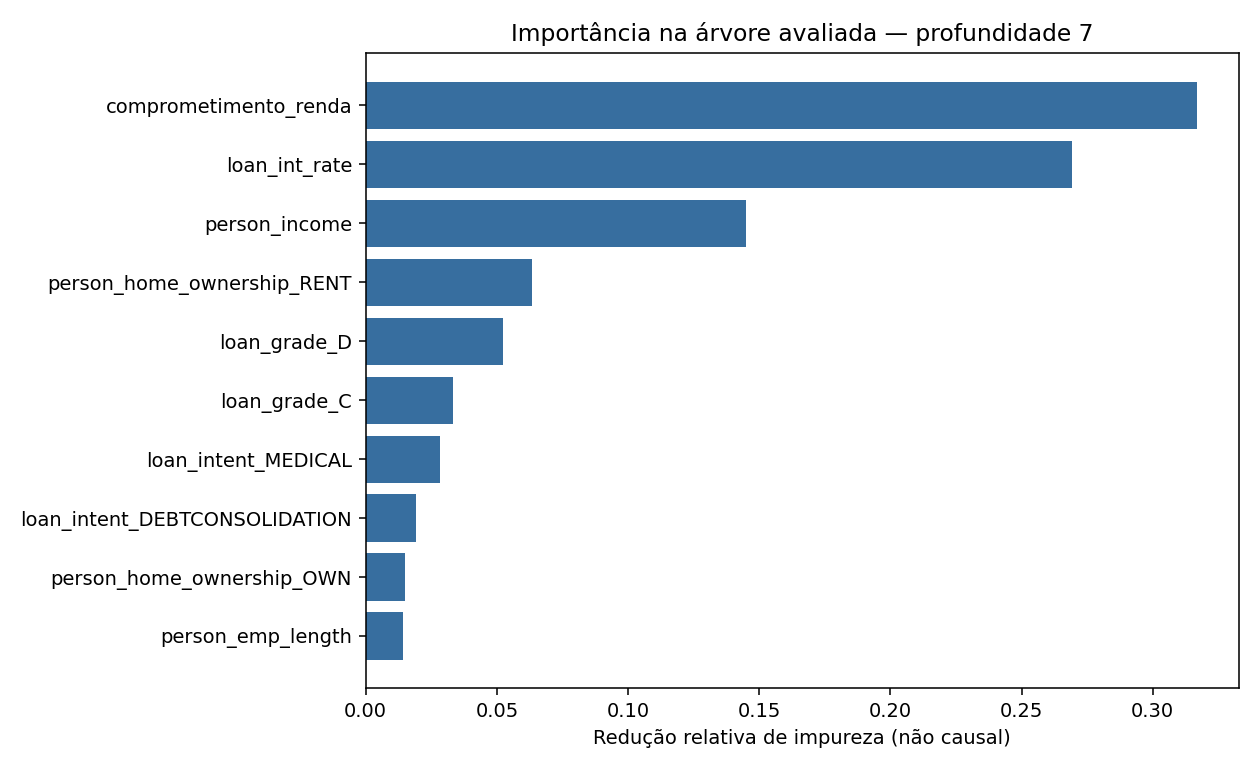

In [11]:
display(Markdown((ROOT / 'documentacao/03_avaliacao_e_veredito.md').read_text()))
display(pd.read_csv(ROOT / 'resultados/avaliacao_teste.csv'))
display(Image(filename=str(ROOT / 'resultados/avaliacao_final/feature_importance_arvore.png')))


                  precision    recall  f1-score   support

      Em dia (0)     0.9174    0.7980    0.8536      5065
Inadimplente (1)     0.5075    0.7433    0.6031      1418

        accuracy                         0.7861      6483
       macro avg     0.7124    0.7707    0.7284      6483
    weighted avg     0.8277    0.7861    0.7988      6483



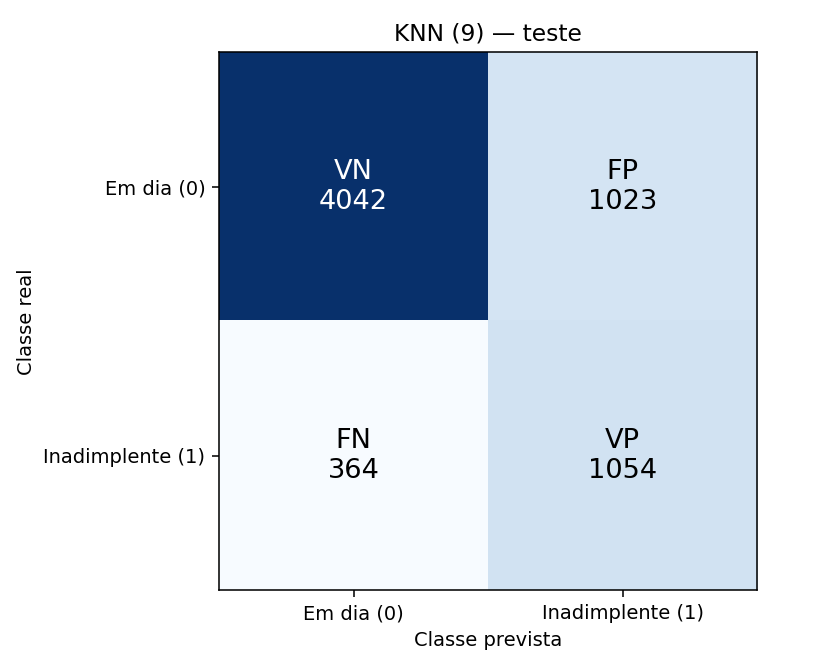

                  precision    recall  f1-score   support

      Em dia (0)     0.9270    0.9504    0.9386      5065
Inadimplente (1)     0.8054    0.7327    0.7674      1418

        accuracy                         0.9028      6483
       macro avg     0.8662    0.8416    0.8530      6483
    weighted avg     0.9004    0.9028    0.9011      6483



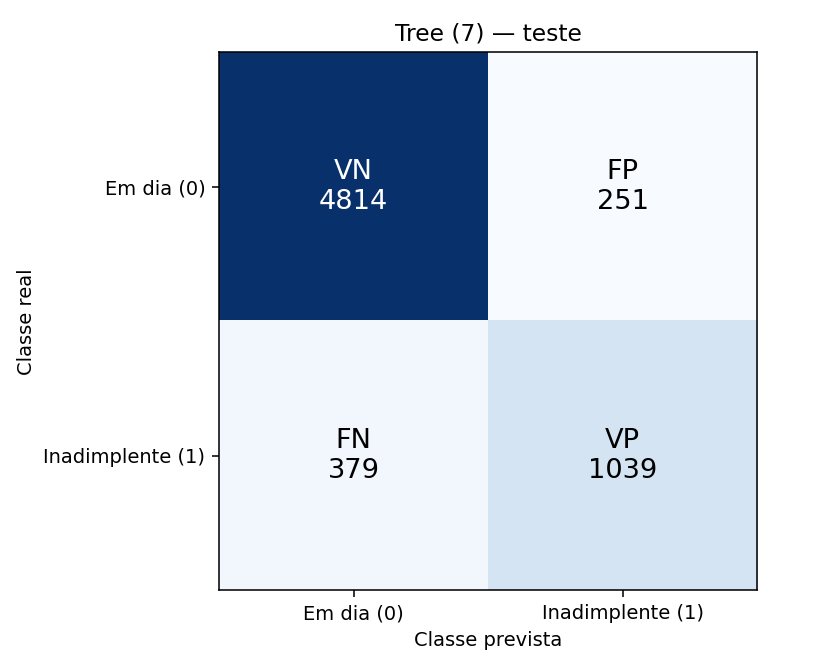

In [12]:
import json
selected = json.loads((ROOT / 'resultados/parametros_selecionados.json').read_text())['selecionados']
for model, param in selected.items():
    prefix = f'knn_k{param}' if model == 'KNN' else f'arvore_depth{param}'
    folder = ROOT / 'resultados/avaliacao_final'
    print((folder / f'{prefix}_classification_report.txt').read_text())
    display(Image(filename=str(folder / f'{prefix}_matriz_confusao.png')))


## Verificação complementar (opcional)

`04_analise_complementar.py` não é exigido pelo problema e não é chamado automaticamente por `03_executar_pipeline.py`. Compara uma referência aleatória estratificada com a árvore completa e uma árvore sem `loan_grade`/`loan_int_rate`, usando só as dobras de treino. Se você já rodou esse script manualmente, o resultado está na seção "Verificação complementar" de `documentacao/03_avaliacao_e_veredito.md` (já exibida acima); a célula abaixo só confirma se essa seção existe.


In [13]:
texto = (ROOT / 'documentacao/03_avaliacao_e_veredito.md').read_text()
if 'Para gerá-la, rode' in texto:
    print('Ainda não rodado: execute notebooks/04_analise_complementar.py para gerar esta seção.')
else:
    print('Já rodado — resultado incluído na exibição de documentacao/03_avaliacao_e_veredito.md acima.')


Já rodado — resultado incluído na exibição de documentacao/03_avaliacao_e_veredito.md acima.


## Limites e integridade

A limitação de dependência do teste histórico já foi detalhada na seção "Limitações" exibida acima (Etapa 6). A base também não informa quando juros e classificação de risco estão disponíveis no momento da decisão. A última célula confere novamente os hashes dos CSVs originais.

In [14]:
from pipeline_credito import verify_originals
verify_originals()
print('Integridade dos CSVs originais confirmada.')


Integridade dos CSVs originais confirmada.
